## Important Notes
### Make sure to install unite with the editable flag.
### If you want 64-bit precision in JAX, you need to set the relevant environment variable: "JAX_ENABLE_X64" = "1"
### If you want to use exponential profiles, this is a hack for now, on line 327 of optimized.py replace integrateVoigt with integrateGaussianLaplace. Currently Cauchy/Exponential profiles cannot be used together.

In [1]:
# some basic imports 
import sys, numpy, scipy, json
import jax, jaxlib
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, hstack,Column
from unite.spectra import NIRSpecSpectra
from unite.fitting import NIRSpecFit

print(sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("jax:", jax.__version__)
print("jaxlib:", jaxlib.__version__)
print("Available backends:", jax.devices())

/Users/ivo/Astro/PROJECTS/UNCOVER/sci/deep/unite/.pixi/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:30) [Clang 18.1.8 ]
numpy: 2.3.5
scipy: 1.15.3
jax: 0.5.3
jaxlib: 0.5.3
Available backends: [CpuDevice(id=0)]


Here is an example of running the code to fit two dispersers for a single spectrum. You create the table of the sources and ensure that they get loaded in correctly. To make sure different dispersers are processed together they must share the same root and srcid. 

In [26]:
spectra_directory = 'spectra'

spec_names = ['rubies-egs53-v4_prism-clear_4233_42046.spec.fits',
              'rubies-egs53-v4_g395m-f290lp_4233_42046.spec.fits']
disps = ['prism'.upper(),'g395m'.upper()]
root = ['rubies-egs53-v4']*len(disps)
grade = [3]*len(disps)
redshift = [5.2777]*len(disps)
srcid = [42046]*len(disps)
spec_table = Table(data=[srcid,spec_names,root,disps,grade,redshift],names=['srcid','file','root','grating','grade','z'])

# check to see what this table looks like
spec_table

srcid,file,root,grating,grade,z
int64,str49,str15,str5,int64,float64
42046,rubies-egs53-v4_prism-clear_4233_42046.spec.fits,rubies-egs53-v4,PRISM,3,5.2777
42046,rubies-egs53-v4_g395m-f290lp_4233_42046.spec.fits,rubies-egs53-v4,G395M,3,5.2777


In [29]:
# we can test whether this table works by loading the NIRSpecSpectra class
# this will read in the spectra files and convert the data to f_lambda units automatically
# the two arguments needed are the table, and the directory where the spectra are stored
spectra = NIRSpecSpectra(rows=spec_table,spectra_directory=spectra_directory)


Now that we know how to load in the data, we can set up the fit itself. The emission lines (and their line types) that we want to fit need to be specified in a configuration file. 
Here you can also specify absorption or cauchy components. 

In [ ]:
# load in the config here
#with open('example-config-narrow.json') as f:
#    config = json.load(f)

#with open('example-config-broad2.json') as f:
#    broad = json.load(f)

#with open('example-config-absorption.json') as f:
#    absorption = json.load(f)
#config['Groups'].update(broad['Groups'])
#config = broad
#config['Groups'].update(absorption['Groups'])
#config['Name'] = 'combined'

# with open('ex2-narrow.json') as f:
#     config = json.load(f)

# with open('ex2-broad.json') as f:
#     broad = json.load(f)
# config['Groups'].update(broad['Groups'])
# config['Name'] = 'combined'

with open('../Opt_config-initial_loosened_broad_H-He.json') as f:
    config = json.load(f)
config['Name'] = 'jg'

with open('example-config-absorption.json') as f:
    absorption = json.load(f)
config['Groups'].update(absorption['Groups'])
config['Name'] = 'jg_abs'

with open('../example-config-all.json', 'w') as f:
    json.dump(config, f, indent=2)

config


{'Name': 'jg_abs',
 'Unit': 'Angstrom',
 'Groups': {'Narrow': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'emission',
     'Lines': [{'Wavelength': 6564.61, 'RelStrength': None},
      {'Wavelength': 4862.68, 'RelStrength': None},
      {'Wavelength': 4341.0, 'RelStrength': None},
      {'Wavelength': 4102.0, 'RelStrength': None},
      {'Wavelength': 3970.0, 'RelStrength': None},
      {'Wavelength': 3889.06, 'RelStrength': None}]},
    {'Name': 'He',
     'LineType': 'emission',
     'Lines': [{'Wavelength': 10830, 'RelStrength': None},
      {'Wavelength': 5017.08, 'RelStrength': None},
      {'Wavelength': 5877.25, 'RelStrength': None},
      {'Wavelength': 3888.6, 'RelStrength': None},
      {'Wavelength': 4120.8, 'RelStrength': None},
      {'Wavelength': 4923.3, 'RelStrength': None},
      {'Wavelength': 6680.0, 'RelStrength': None},
      {'Wavelength': 3867.5, 'RelStrength': None}]},
    {'Name': 'Pa',
     'LineType': 'emissi

Running the fit is now easy! We use MCMC sampling as implemented in numpyro NUTS. Let's use 500 samples for warm-up, and 1000 for the actual sampling.

The fitting produces some files that store the full chains and a summary of results, and also a figure showing the fit. You can choose the location where to store these files.

In [40]:
# run the fit
NIRSpecFit(config, spec_table, spectra_directory=spectra_directory, output_directory='out', N=500, num_warmup=100)


{'Name': 'HI', 'LineType': 'emission', 'Lines': [{'Wavelength': 6564.61, 'RelStrength': None}, {'Wavelength': 4862.68, 'RelStrength': None}, {'Wavelength': 4341.0, 'RelStrength': None}, {'Wavelength': 4102.0, 'RelStrength': None}, {'Wavelength': 3970.0, 'RelStrength': None}, {'Wavelength': 3889.06, 'RelStrength': None}]}
{'Name': 'He', 'LineType': 'emission', 'Lines': [{'Wavelength': 10830, 'RelStrength': None}, {'Wavelength': 5017.08, 'RelStrength': None}, {'Wavelength': 5877.25, 'RelStrength': None}, {'Wavelength': 3888.6, 'RelStrength': None}, {'Wavelength': 4120.8, 'RelStrength': None}, {'Wavelength': 4923.3, 'RelStrength': None}, {'Wavelength': 6680.0, 'RelStrength': None}, {'Wavelength': 3867.5, 'RelStrength': None}]}
{'Name': 'Pa', 'LineType': 'emission', 'Lines': [{'Wavelength': 12818.1, 'RelStrength': None}, {'Wavelength': 10049.4, 'RelStrength': None}, {'Wavelength': 9545.98, 'RelStrength': None}, {'Wavelength': 10938.1, 'RelStrength': None}]}
{'Name': '[NeIII]', 'LineType': 

sample: 100%|██████████| 600/600 [04:03<00:00,  2.46it/s, 1023 steps of size 5.45e-04. acc. prob=0.82]


* To change the *shape* of the priors we can edit the unite/priors.py file directly

* To change the *range* of the priors we can edit the unite/defaults.py file directly

* To change the width of the wavelength range used to fit, or the width used to find an initial estimate of the line fluxes, we can edit the unite/defaults.py file directly


{'Name': 'HI', 'LineType': 'emission', 'Lines': [{'Wavelength': 6564.61, 'RelStrength': None}, {'Wavelength': 4862.68, 'RelStrength': None}, {'Wavelength': 4341.0, 'RelStrength': None}, {'Wavelength': 4102.0, 'RelStrength': None}, {'Wavelength': 3970.0, 'RelStrength': None}, {'Wavelength': 3889.06, 'RelStrength': None}]}
{'Name': 'He', 'LineType': 'emission', 'Lines': [{'Wavelength': 10830, 'RelStrength': None}, {'Wavelength': 5017.08, 'RelStrength': None}, {'Wavelength': 5877.25, 'RelStrength': None}, {'Wavelength': 3888.6, 'RelStrength': None}, {'Wavelength': 4120.8, 'RelStrength': None}, {'Wavelength': 4923.3, 'RelStrength': None}, {'Wavelength': 6680.0, 'RelStrength': None}, {'Wavelength': 3867.5, 'RelStrength': None}]}
{'Name': 'Pa', 'LineType': 'emission', 'Lines': [{'Wavelength': 12818.1, 'RelStrength': None}, {'Wavelength': 10049.4, 'RelStrength': None}, {'Wavelength': 9545.98, 'RelStrength': None}, {'Wavelength': 10938.1, 'RelStrength': None}]}
{'Name': '[NeIII]', 'LineType': 

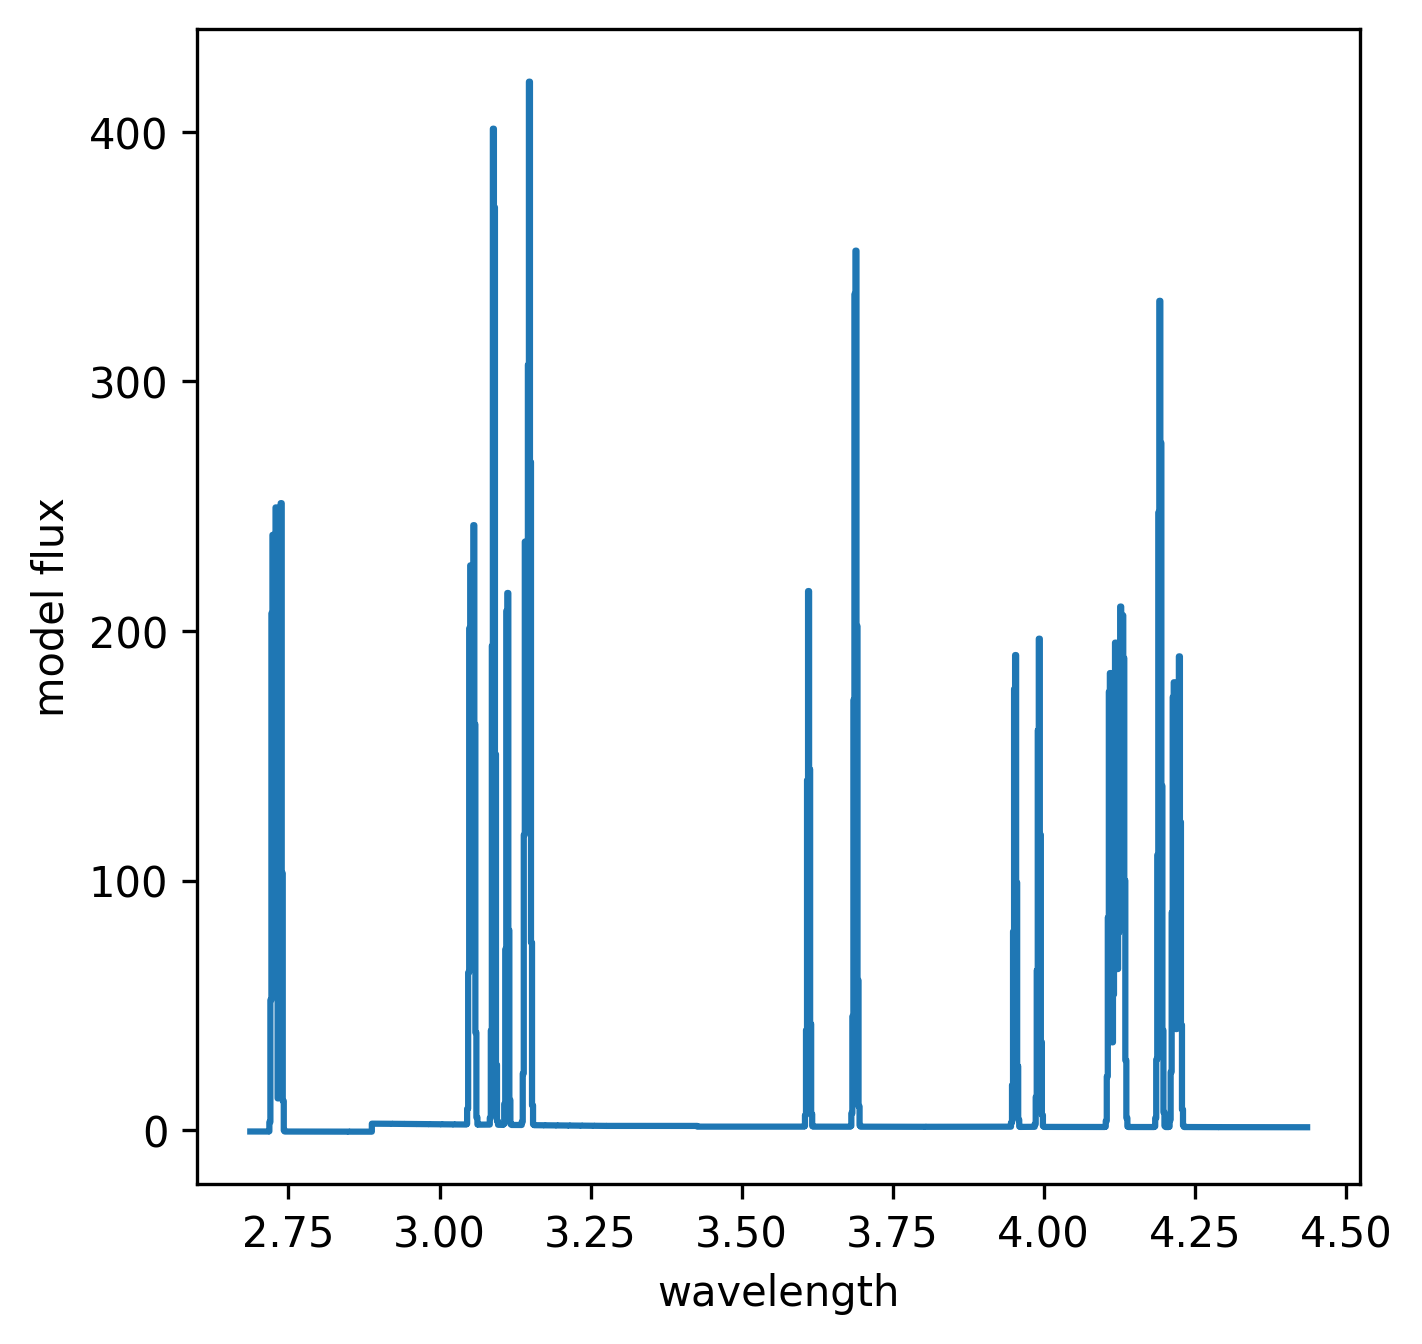

In [35]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from numpyro import handlers
from unite.fitting import NIRSpecModelArgs
from unite.model import multiSpecModel

# Build model args (restricts config, computes centers, etc.)
config_r, model_args = NIRSpecModelArgs(config, spec_table, spectra_directory)
spectra, matrices, linetypes_all, line_centers, line_estimates_eq, cont_regs, cont_guesses = model_args

# Deterministic parameters: unit fluxes, constant FWHM
fwhm_guess = jnp.ones_like(line_estimates_eq) * 300.0
data = {"flux_all": jnp.ones_like(line_estimates_eq), "fwhm_all": fwhm_guess}

with handlers.seed(rng_seed=0):   # add RNG for remaining samples
    with handlers.substitute(data=data), handlers.trace() as tr:
        multiSpecModel(*model_args)

spec0 = spectra.spectra[1].name
model_flux = tr[f"{spec0}_model"]["value"]
wave = spectra.spectra[1].wave

plt.step(wave, model_flux, where="mid")
plt.xlabel("wavelength")
plt.ylabel("model flux")
plt.show()

In [22]:
#tr


1500.0

In [58]:
import cProfile
from numpyro import handlers
from numpyro.infer.util import log_density
import jax

# Build model args once
config_r, model_args = NIRSpecModelArgs(config, spec_table, spectra_directory)

# JIT-compiled log-probability of the model

def make_logprob(model, model_args):
    def lp(unconstrained_params):
        with handlers.seed(rng_seed=0):
            return log_density(model, model_args, {}, unconstrained_params)[0]
    return jax.jit(lp)

lp = make_logprob(multiSpecModel, model_args)

# Warm up the JIT (compilation happens on first call)
_ = lp({})  # Empty params lets log_density build the unconstrained map

# Profile repeated calls to the JITted logprob
with cProfile.Profile() as pr:
    for _ in range(1000):
        _ = lp({})  # fast path after first call
    pr.print_stats(sort="tottime")


{'Name': 'HI', 'LineType': 'emission', 'Lines': [{'Wavelength': 6564.61, 'RelStrength': None}, {'Wavelength': 4862.68, 'RelStrength': None}, {'Wavelength': 4341.0, 'RelStrength': None}, {'Wavelength': 4102.0, 'RelStrength': None}, {'Wavelength': 3970.0, 'RelStrength': None}, {'Wavelength': 3889.06, 'RelStrength': None}]}
{'Name': 'He', 'LineType': 'emission', 'Lines': [{'Wavelength': 10830, 'RelStrength': None}, {'Wavelength': 5017.08, 'RelStrength': None}, {'Wavelength': 5877.25, 'RelStrength': None}, {'Wavelength': 3888.6, 'RelStrength': None}, {'Wavelength': 4120.8, 'RelStrength': None}, {'Wavelength': 4923.3, 'RelStrength': None}, {'Wavelength': 6680.0, 'RelStrength': None}, {'Wavelength': 3867.5, 'RelStrength': None}]}
{'Name': 'Pa', 'LineType': 'emission', 'Lines': [{'Wavelength': 12818.1, 'RelStrength': None}, {'Wavelength': 10049.4, 'RelStrength': None}, {'Wavelength': 9545.98, 'RelStrength': None}, {'Wavelength': 10938.1, 'RelStrength': None}]}
{'Name': '[NeIII]', 'LineType': 

In [63]:
import jax.random as jr
from numpyro.infer import MCMC, NUTS

# Build model args once
config_r, model_args = NIRSpecModelArgs(config, spec_table, spectra_directory)

# JIT-compiled NUTS sampler; keep iterations small for a quick demo
nuts = NUTS(multiSpecModel)
mcmc = MCMC(nuts, num_warmup=50, num_samples=100, progress_bar=False, chain_method='sequential')

with cProfile.Profile() as pr:
    mcmc.run(jr.key(0), *model_args)
    pr.print_stats(sort="tottime")

samples = mcmc.get_samples()
print({k: v.shape for k, v in samples.items()})


{'Name': 'HI', 'LineType': 'emission', 'Lines': [{'Wavelength': 6564.61, 'RelStrength': None}, {'Wavelength': 4862.68, 'RelStrength': None}, {'Wavelength': 4341.0, 'RelStrength': None}, {'Wavelength': 4102.0, 'RelStrength': None}, {'Wavelength': 3970.0, 'RelStrength': None}, {'Wavelength': 3889.06, 'RelStrength': None}]}
{'Name': 'He', 'LineType': 'emission', 'Lines': [{'Wavelength': 10830, 'RelStrength': None}, {'Wavelength': 5017.08, 'RelStrength': None}, {'Wavelength': 5877.25, 'RelStrength': None}, {'Wavelength': 3888.6, 'RelStrength': None}, {'Wavelength': 4120.8, 'RelStrength': None}, {'Wavelength': 4923.3, 'RelStrength': None}, {'Wavelength': 6680.0, 'RelStrength': None}, {'Wavelength': 3867.5, 'RelStrength': None}]}
{'Name': 'Pa', 'LineType': 'emission', 'Lines': [{'Wavelength': 12818.1, 'RelStrength': None}, {'Wavelength': 10049.4, 'RelStrength': None}, {'Wavelength': 9545.98, 'RelStrength': None}, {'Wavelength': 10938.1, 'RelStrength': None}]}
{'Name': '[NeIII]', 'LineType': 

{'G395M_cont': (100, 843), 'G395M_flux': (100,), 'G395M_lines': (100, 843, 38), 'G395M_lsf': (100, 38), 'G395M_model': (100, 843), 'G395M_offset': (100,), 'PRISM_cont': (100, 176), 'PRISM_flux': (100,), 'PRISM_lines': (100, 176, 38), 'PRISM_lsf': (100, 38), 'PRISM_model': (100, 176), 'PRISM_offset': (100,), 'cont_angle': (100, 3), 'cont_center': (100, 3), 'cont_offset': (100, 3), 'ew_all': (100, 38), 'flux_all': (100, 38), 'flux_orig': (100, 37), 'fwhm_all': (100, 38), 'fwhm_orig': (100, 4), 'lsf_scale': (100,), 'redshift_all': (100, 38), 'redshift_orig': (100, 4)}
